In [1]:
from ucimlrepo import fetch_ucirepo

steel_plates_faults = fetch_ucirepo(id=198)

from torch.utils.data import DataLoader, TensorDataset
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
import numpy as np
import matplotlib.pyplot as plt

device = "cuda" if torch.cuda.is_available() else "cpu"

X = steel_plates_faults.data.features
y = steel_plates_faults.data.targets

y = np.argmax(y.values, axis=1)

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

X_train_tensor = torch.from_numpy(X_train_scaled).float().to(device)
X_test_tensor = torch.from_numpy(X_test_scaled).float().to(device)
y_train_tensor = torch.from_numpy(y_train).long().to(device)
y_test_tensor = torch.from_numpy(y_test).long().to(device)

train_dataset = TensorDataset(X_train_tensor, y_train_tensor)
train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True)


# --- MODEL DLA TESTU K2 ---
class NetK2(nn.Module):
    def __init__(self, k2_size):
        super(NetK2, self).__init__()
        self.fc1 = nn.Linear(27, 128) # K1 stałe = 128
        self.fc2 = nn.Linear(128, k2_size)
        self.fc3 = nn.Linear(k2_size, 7)

    def forward(self, x):
        x = F.relu(self.fc1(x))
        x = F.relu(self.fc2(x))
        x = self.fc3(x)
        return x

# --- KONFIGURACJA ---
k2_values = [8, 16, 32, 64, 128]
k2_results = {}
epochs = 20
best_lr = 0.001
num_repeats = 5

print(f"\nRozpoczynam Eksperyment 3b (Urządzenie: {device})")

for k2 in k2_values:
    print(f"\n>>> Testowanie K2 = {k2}")
    run_accs = []
    for i in range(num_repeats):
        model = NetK2(k2).to(device)
        optimizer = optim.Adam(model.parameters(), lr=best_lr)
        criterion = nn.CrossEntropyLoss()
        
        for epoch in range(epochs):
            model.train()
            for x_batch, y_batch in train_loader:
                optimizer.zero_grad()
                loss = criterion(model(x_batch), y_batch)
                loss.backward()
                optimizer.step()
        
        model.eval()
        with torch.no_grad():
            acc = (model(X_test_tensor).argmax(1) == y_test_tensor).float().mean().item() * 100
            run_accs.append(acc)
            print(f"   Próba {i+1}: {acc:.2f}%")
    k2_results[str(k2)] = run_accs



Rozpoczynam Eksperyment 3b (Urządzenie: cuda)

>>> Testowanie K2 = 8
   Próba 1: 73.78%
   Próba 2: 74.55%
   Próba 3: 75.32%
   Próba 4: 74.81%
   Próba 5: 75.32%

>>> Testowanie K2 = 16
   Próba 1: 76.09%
   Próba 2: 74.81%
   Próba 3: 73.52%
   Próba 4: 74.29%
   Próba 5: 74.29%

>>> Testowanie K2 = 32
   Próba 1: 74.81%
   Próba 2: 76.09%
   Próba 3: 74.81%
   Próba 4: 76.09%
   Próba 5: 73.26%

>>> Testowanie K2 = 64
   Próba 1: 74.81%
   Próba 2: 74.81%
   Próba 3: 75.32%
   Próba 4: 74.55%
   Próba 5: 75.58%

>>> Testowanie K2 = 128
   Próba 1: 72.49%
   Próba 2: 76.61%
   Próba 3: 74.04%
   Próba 4: 74.81%
   Próba 5: 74.04%


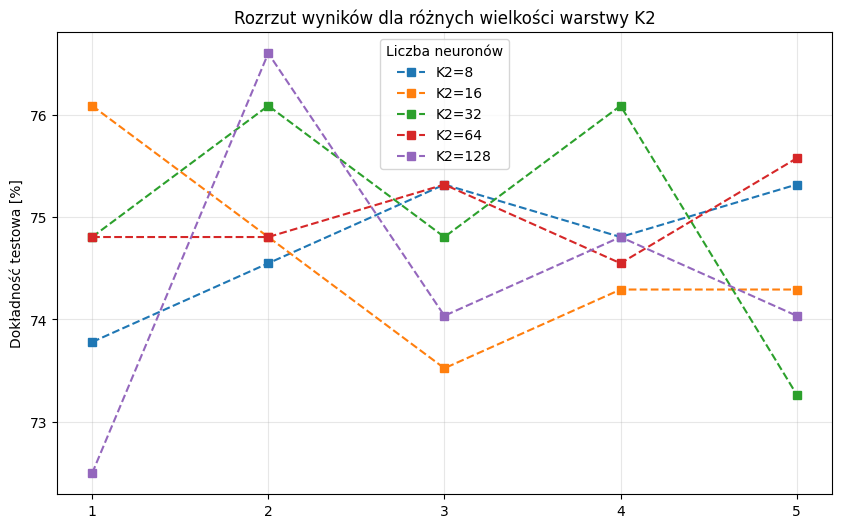

In [2]:
# --- WYKRESY K2 ---
plt.figure(figsize=(10, 6))
for k2_val, accs in k2_results.items():
    plt.plot(range(1, num_repeats + 1), accs, marker='s', linestyle='--', label=f'K2={k2_val}')
plt.title('Rozrzut wyników dla różnych wielkości warstwy K2')
plt.xticks(range(1, num_repeats + 1))
plt.ylabel('Dokładność testowa [%]')
plt.legend(title="Liczba neuronów")
plt.grid(True, alpha=0.3)
plt.show()

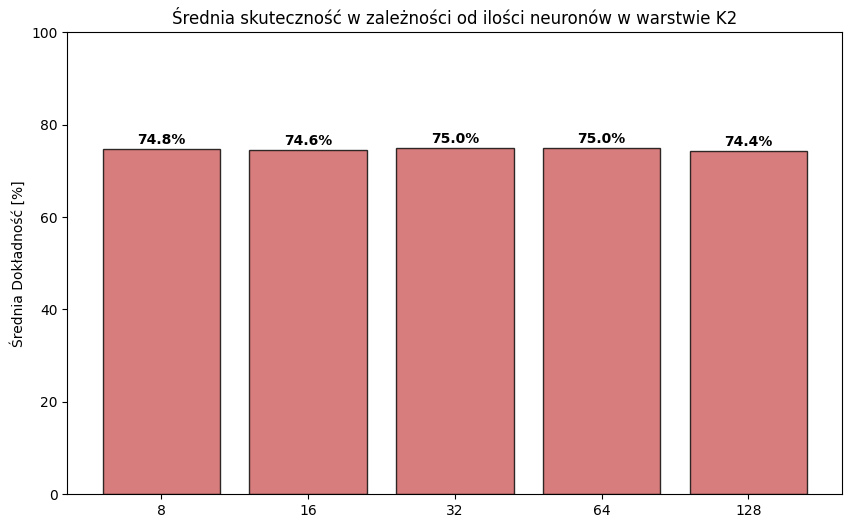

In [3]:
plt.figure(figsize=(10, 6))
k2_means = [np.mean(k2_results[str(k)]) for k in k2_values]
bars = plt.bar([str(k) for k in k2_values], k2_means, color='indianred', alpha=0.8, edgecolor='black')
plt.title('Średnia skuteczność w zależności od ilości neuronów w warstwie K2')
plt.ylabel('Średnia Dokładność [%]')
plt.ylim(0, 100)
for bar in bars:
    yval = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2, yval + 1, f'{yval:.1f}%', ha='center', fontweight='bold')
plt.show()

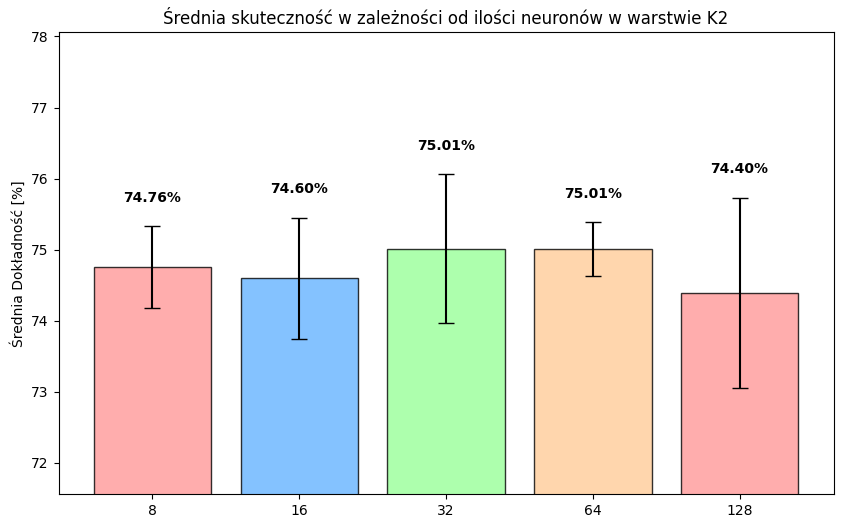

In [9]:
plt.figure(figsize=(10, 6))
k2_means = [np.mean(k2_results[str(k)]) for k in k2_values]
k2_std = [np.std(k2_results[str(k)]) for k in k2_values]

colors = ['#ff9999','#66b3ff','#99ff99','#ffcc99']

bars = plt.bar([str(k) for k in k2_values], k2_means, color=colors, alpha=0.8, edgecolor='black', yerr=k2_std, error_kw={'ecolor': 'black', 'elinewidth': 1.5}, capsize=6)
plt.title('Średnia skuteczność w zależności od ilości neuronów w warstwie K2')
plt.ylabel('Średnia Dokładność [%]')
ymin = min([s - o for s, o in zip(k2_means, k2_std)]) - 1.5
ymax = max([s + o for s, o in zip(k2_means, k2_std)]) + 2.0
plt.ylim(ymin, ymax)
# for bar in bars:
#     yval = bar.get_height()
#     plt.text(bar.get_x() + bar.get_width()/2, yval + 1, f'{yval:.1f}%', ha='center', fontweight='bold')
for i, bar in enumerate(bars):
    yval = bar.get_height()
    sd = k2_std[i]
    # y_val2 = bar.get_err()
    # yval = bar.get_height()
    plt.text(
        bar.get_x() + bar.get_width()/2, 
        yval + sd + 0.3, # 0.3% powyżej górnego wąsa błędu
        f'{yval:.2f}%', 
        ha='center', 
        va='bottom', 
        fontweight='bold',
        color='black'
    )
plt.show()